# CSE570 – Machine Learning with Python
## Unit II: Exploratory Data Analysis and Feature Engineering

> **Topics:** EDA, visualization, correlation analysis, outlier detection, feature selection, feature transformation, data imbalance handling, and preprocessing pipelines.

---

# 1. Exploratory Data Analysis (EDA)

## What is EDA?

**Exploratory Data Analysis (EDA)** is the process of understanding a dataset before applying a machine-learning algorithm.

EDA helps us answer:

- What type of data is available?
- Are values missing?
- Are duplicate records present?
- Are there unusual or extreme values?
- How are variables distributed?
- Which variables are related?
- Is the target class balanced?

<div style="background:#E8F4FD;padding:10px;border-left:5px solid #1976D2;">
<b>Key Idea:</b> Machine-learning models learn from the data we provide. If the data contains errors, noise, missing values, or misleading patterns, the model will also learn from them.
</div>

### Basic inspection

In [9]:
# Import pandas for reading and working with tabular data
# Import pandas for reading and working with tabular data.
import pandas as pd

# Load the customer churn dataset into a DataFrame named 'df'
# Load the CSV dataset into a pandas DataFrame.
df = pd.read_csv("/content/CSE570_Unit2_Customer_Churn_Dataset.csv")

# Display the first 5 rows to understand the structure of the dataset
# Display the first few rows to inspect the dataset structure.
print(df.head())

# Display the number of rows and columns in the dataset
# Display the number of rows and columns.
print(df.shape)

# Show column names, data types, non-null counts, and memory usage
# Show column names, data types, non-null counts, and memory usage.
df.info()

# Generate summary statistics for numerical columns
# Generate descriptive statistics for numerical columns.
df.describe()

   CustomerID   Age  Gender  TenureMonths  MonthlyCharges  TotalCharges  \
0  CUST100000  27.0    Male            29           63.58           NaN   
1  CUST100001  36.0  Female            36          100.15       3496.65   
2  CUST100002  40.0    Male            14           77.08       1056.23   
3  CUST100003  23.0  Female            54           30.90       1533.91   
4  CUST100004  56.0    Male            55           59.27       3255.20   

   SupportCalls  SatisfactionScore    ContractType PaymentMethod  \
0             2                  1        One Year   Net Banking   
1             3                  4        One Year   Credit Card   
2             1                  4  Month-to-Month           UPI   
3             1                  4        One Year   Credit Card   
4             4                  4  Month-to-Month    Debit Card   

   InternetUsageGB  AnnualIncome Region  Churn  
0           152.96      31172.97  South      0  
1           118.13      67921.36  North   

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportCalls,SatisfactionScore,InternetUsageGB,AnnualIncome,Churn
count,1178.000000,1208.000000,1184.000000,1166.000000,1208.000000,1208.000000,1176.000000,1172.000000,1208.000000
mean,38.552632,26.208609,72.929267,1878.359297,2.014073,3.355960,83.196144,54431.737415,0.111755
std,11.280137,17.118899,25.656271,1418.960246,1.427265,0.996654,59.580689,28490.405532,0.315195
min,18.000000,1.000000,20.000000,20.000000,0.000000,1.000000,9.300000,18000.000000,0.000000
25%,31.000000,13.000000,57.890000,884.565000,1.000000,3.000000,47.107500,34595.750000,0.000000
50%,39.000000,22.000000,71.820000,1504.950000,2.000000,3.000000,70.245000,48161.240000,0.000000
75%,46.000000,35.000000,86.065000,2492.755000,3.000000,4.000000,104.042500,67789.680000,0.000000
max,75.000000,72.000000,299.558842,10604.410000,7.000000,5.000000,952.569688,276803.450000,1.000000


- `head()` → first few rows
- `shape` → number of rows and columns
- `info()` → data types and missing values
- `describe()` → statistical summary

---

# 2. Missing Values

A **missing value** means information is unavailable for a particular observation.

Example:

| Age | Income |
|---|---|
| 25 | 50000 |
| NaN | 65000 |

### Check missing values

In [3]:
# Check the number of missing (NaN) values in each column
# Count missing values in each column.
df.isnull().sum()

,0
CustomerID,0
Age,30
Gender,18
TenureMonths,0
MonthlyCharges,24
TotalCharges,42
SupportCalls,0
SatisfactionScore,0
ContractType,0
PaymentMethod,24


### Common treatments

- Numerical feature → mean or median
- Categorical feature → mode
- Large amount of missing data → consider removing the feature
- Missingness has meaning → create a separate category/indicator

In [4]:
# Replace missing Age values with the median Age
# Median is preferred because it is less affected by extreme values/outliers
# Replace missing Age values using the median.
df["Age"] = df["Age"].fillna(df["Age"].median())

<div style="background:#FFF8E1;padding:10px;border-left:5px solid #FFB300;">
<b>Why median?</b> Median is less affected by extreme values than the mean.
</div>

---

# 3. Duplicate Records

Duplicate records may occur because of repeated data entry or merging datasets.

In [5]:
# Count how many rows are exact duplicates
# Count exact duplicate rows.
df.duplicated().sum()

np.int64(8)

Remove exact duplicates:

In [10]:
# Remove rows that are exact duplicates
# The cleaned DataFrame is stored back in 'df'
# Remove exact duplicate rows.
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

**Important:** Do not remove duplicates blindly. In transaction data, two identical records may represent two valid transactions.

---


# 4. Data Visualization

**Data visualization** converts raw data into graphs so that patterns, trends, relationships, class differences, skewness, and unusual observations become easier to understand.

Visualization is an important part of EDA because statistical tables alone may hide important behavior in the data.

## Why do we visualize data?

Visualization helps us answer questions such as:

- Is a numerical variable normally distributed or skewed?
- Are extreme observations present?
- Which category occurs most frequently?
- Does a feature differ between churned and retained customers?
- Do two numerical features move together?
- Is the target class balanced?
- Are there clusters or unusual groups in the data?

<div style="background:#E8F4FD;padding:10px;border-left:5px solid #1976D2;">
<b>Professor's Rule:</b> Choose the graph according to the type of variable and the question you want to answer. A graph should reveal information, not merely decorate the analysis.
</div>

## Choosing the Correct Plot

| Question | Variable Type | Recommended Plot |
|---|---|---|
| What is the distribution? | One numerical | Histogram |
| Are there possible outliers? | One numerical | Boxplot |
| How frequent is each category? | One categorical | Bar plot |
| How do two numerical variables relate? | Numerical + Numerical | Scatter plot |
| How does a numerical feature differ across groups? | Numerical + Categorical | Boxplot |
| How do categories relate to the target? | Categorical + Target | Grouped/stacked bar |
| How are many numerical variables related? | Multiple numerical | Correlation heatmap |
| Is the target balanced? | Target category | Count/Bar plot |

---

## 4.1 Histogram — Understanding Distribution

A **histogram** divides numerical values into intervals called **bins** and displays how many observations fall into each interval.

It helps identify:

- Symmetric distributions
- Positive or negative skewness
- Multiple peaks
- Long tails
- Possible extreme values

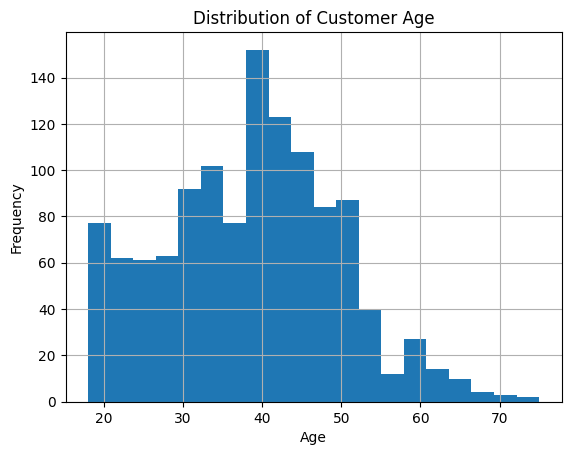

In [7]:
# Import matplotlib for creating graphs
# Import matplotlib for creating graphs.
import matplotlib.pyplot as plt

# Create a histogram of the Age column
# bins=20 divides the Age range into 20 intervals
# Create a histogram of the Age feature.
df["Age"].hist(bins=20)

# Label the x-axis
# Label the x-axis.
plt.xlabel("Age")

# Label the y-axis
# Label the y-axis.
plt.ylabel("Frequency")

# Add a descriptive title
# Add a descriptive graph title.
plt.title("Distribution of Customer Age")

# Display the graph
# Display the graph.
plt.show()

### How to interpret it

If most values occur on the left and a long tail extends toward larger values, the distribution is **positively skewed**.

For example, income variables are often positively skewed because most people have moderate income while a few observations have very high income.

### Compare several numerical features

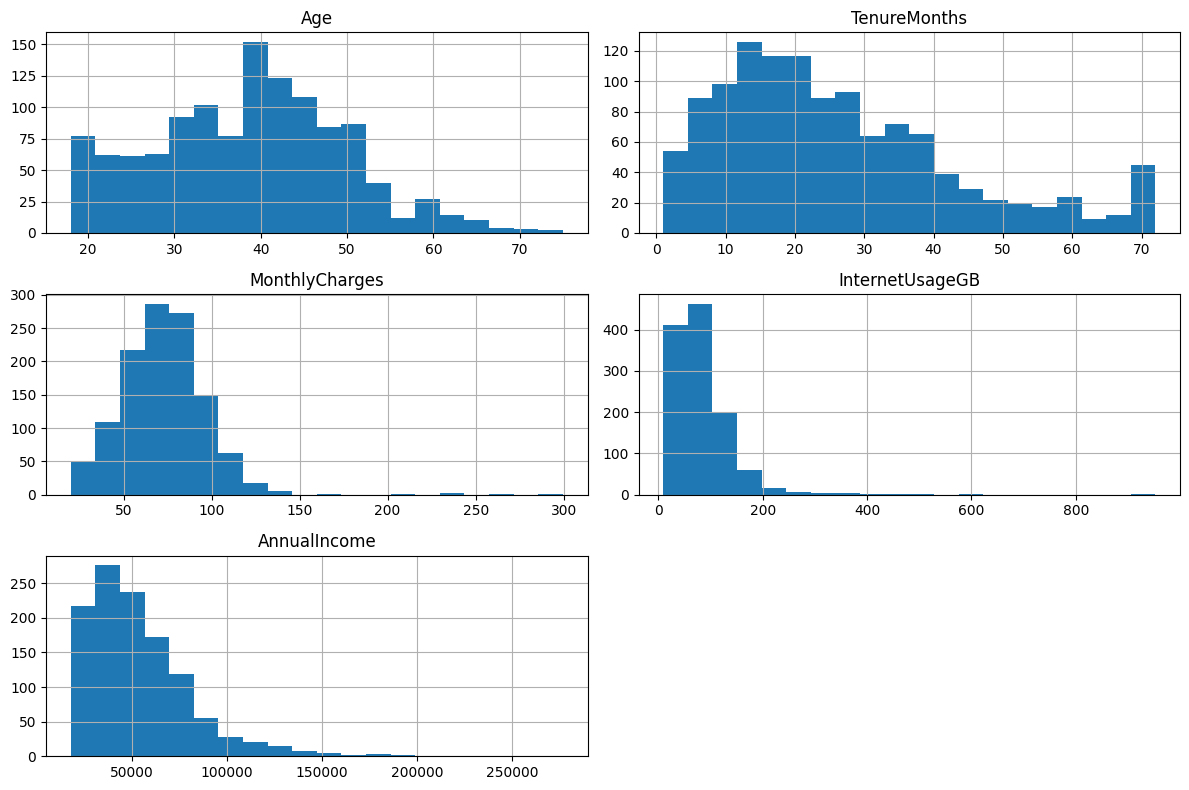

In [8]:
# Select multiple numerical features whose distributions we want to compare
df[
    ["Age", "TenureMonths", "MonthlyCharges",
     "InternetUsageGB", "AnnualIncome"]

# Create a separate histogram for each selected feature
# figsize controls the overall figure size and bins controls the number of intervals
].hist(figsize=(12, 8), bins=20)

# Adjust spacing automatically so labels do not overlap
# Adjust spacing so plot elements do not overlap.
plt.tight_layout()

# Display all histograms
# Display the graph.
plt.show()

This allows us to quickly compare the shape of several features.

---

## 4.2 Boxplot — Distribution and Outliers

A **boxplot** summarizes a numerical feature using quartiles.

It displays:

- Minimum non-outlier value
- Q1
- Median
- Q3
- Maximum non-outlier value
- Potential outliers

In [ ]:
# Create a figure of width 8 inches and height 3 inches
# Create a new figure with the specified size.
plt.figure(figsize=(8, 3))

# Draw a boxplot for MonthlyCharges
# dropna() removes missing values because the plot should use valid numerical values
# vert=False makes the boxplot horizontal
# Create a boxplot.
plt.boxplot(
    df["MonthlyCharges"].dropna(),
    vert=False
)

# Label the horizontal axis
# Label the x-axis.
plt.xlabel("Monthly Charges")

# Add a title to explain what the graph represents
# Add a descriptive graph title.
plt.title("Boxplot of Monthly Charges")

# Display the boxplot
# Display the graph.
plt.show()

### Interpretation

Points lying far beyond the whiskers are potential outliers.

However:

> A boxplot detects unusual values; it does not prove that those values are incorrect.

---

## 4.3 Bar Plot — Categorical Variables

A **bar plot** compares frequencies or values across categories.

In [ ]:
# Count customers in each contract category
# plot(kind="bar") converts those counts into a bar chart
# Count contract categories and display them as a bar chart.
df["ContractType"].value_counts().plot(kind="bar")

# Label the x-axis with the categorical feature name
# Label the x-axis.
plt.xlabel("Contract Type")

# Label the y-axis with the frequency being displayed
# Label the y-axis.
plt.ylabel("Number of Customers")

# Add a suitable graph title
# Add a descriptive graph title.
plt.title("Customers by Contract Type")

# Rotate category labels slightly so they are easier to read
# Adjust x-axis tick labels for readability.
plt.xticks(rotation=20)

# Display the bar chart
# Display the graph.
plt.show()

### What can we learn?

We can quickly identify:

- Most common category
- Least common category
- Imbalanced categorical features

---

## 4.4 Target-Class Visualization

Before classification, always inspect the target distribution.

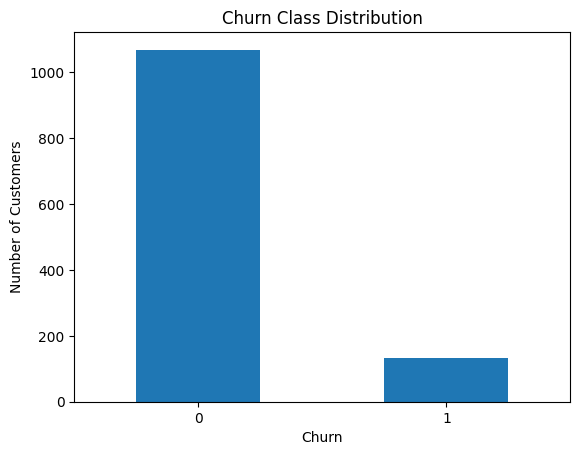

In [12]:
# Count observations in each Churn class
# sort_index() keeps class labels such as 0 and 1 in logical order
# Count observations in each target class.
df["Churn"].value_counts().sort_index().plot(kind="bar")

# Label the target classes on the x-axis
# Label the x-axis.
plt.xlabel("Churn")

# Show how many customers belong to each class
# Label the y-axis.
plt.ylabel("Number of Customers")

# Add a descriptive title
# Add a descriptive graph title.
plt.title("Churn Class Distribution")

# Keep class labels horizontal
# Adjust x-axis tick labels for readability.
plt.xticks(rotation=0)

# Display the class-distribution plot
# Display the graph.
plt.show()

If class `0` has many more observations than class `1`, the target is imbalanced.

---

## 4.5 Grouped Bar Plot — Category vs Target

We may want to know whether churn differs by contract type.

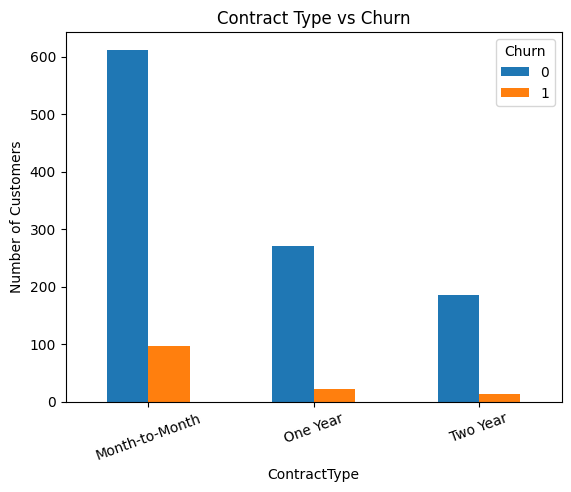

In [11]:
# Build a frequency table between ContractType and Churn
# Rows represent contract types and columns represent churn classes
# Create a cross-tabulation between categorical variables.
pd.crosstab(
    df["ContractType"],
    df["Churn"]

# Plot the cross-tabulation as grouped bars
).plot(kind="bar")

# Label the y-axis
# Label the y-axis.
plt.ylabel("Number of Customers")

# Add a title to describe the comparison
# Add a descriptive graph title.
plt.title("Contract Type vs Churn")

# Rotate contract-type labels for readability
# Adjust x-axis tick labels for readability.
plt.xticks(rotation=20)

# Display the grouped bar chart
# Display the graph.
plt.show()

### Interpretation

If the proportion of churned customers is much larger for one contract type, that feature may contain useful predictive information.

A percentage table is even more informative:

In [ ]:
# Create a cross-tabulation between ContractType and Churn
# Create a normalized cross-tabulation between ContractType and Churn.
contract_churn = pd.crosstab(
    df["ContractType"],
    df["Churn"],

    # normalize="index" converts counts within each contract type into proportions
    normalize="index"

# Multiply by 100 to convert proportions into percentages
) * 100

# Display the churn percentage for each contract type
# Display the result.
print(contract_churn)

---

## 4.6 Scatter Plot — Relationship Between Numerical Features

A **scatter plot** represents each observation as one point.

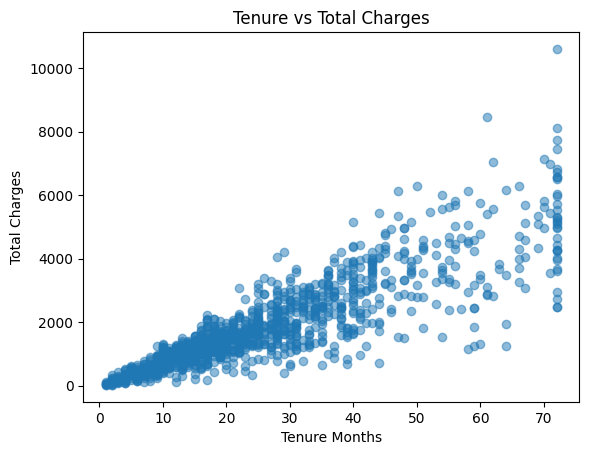

In [13]:
# Create a scatter plot to study the relationship between two numerical features
# Create a scatter plot.
plt.scatter(
    # Values on the x-axis
    df["TenureMonths"],

    # Values on the y-axis
    df["TotalCharges"],

    # Make points slightly transparent so overlapping observations are visible
    alpha=0.5
)

# Label the axes
# Label the x-axis.
plt.xlabel("Tenure Months")
# Label the y-axis.
plt.ylabel("Total Charges")

# Add a title
# Add a descriptive graph title.
plt.title("Tenure vs Total Charges")

# Display the scatter plot
# Display the graph.
plt.show()

Scatter plots can reveal:

- Positive relationships
- Negative relationships
- No clear relationship
- Clusters
- Non-linear behavior
- Outliers

### Add the target class

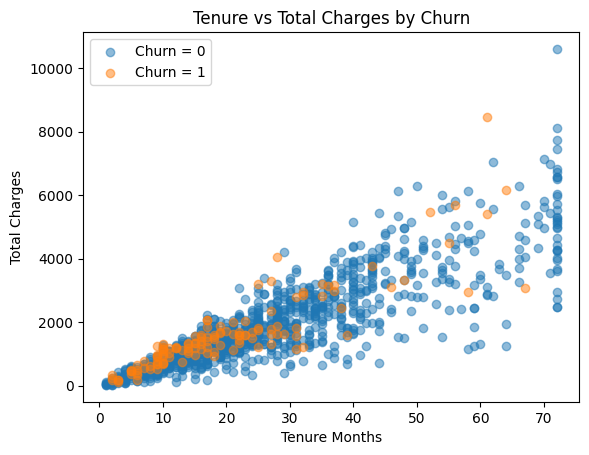

In [14]:
# Loop through each unique churn class, for example 0 and 1
# Loop through each churn class so the classes can be plotted separately.
for churn_class in sorted(df["Churn"].unique()):

    # Keep only the rows belonging to the current churn class
    # Keep only rows belonging to the current churn class.
    subset = df[df["Churn"] == churn_class]

    # Plot the current class on the same scatter plot
    # Create a scatter plot.
    plt.scatter(
        subset["TenureMonths"],
        subset["TotalCharges"],

        # Transparency helps when many points overlap
        alpha=0.5,

        # This label will appear in the legend
        label=f"Churn = {churn_class}"
    )

# Label the axes
# Label the x-axis.
plt.xlabel("Tenure Months")
# Label the y-axis.
plt.ylabel("Total Charges")

# Add a graph title
# Add a descriptive graph title.
plt.title("Tenure vs Total Charges by Churn")

# Display a legend so we can identify each churn class
plt.legend()

# Show the final plot
# Display the graph.
plt.show()

This helps determine whether the two target classes occupy different regions of the feature space.

---

## 4.7 Numerical Feature vs Categorical Group

Boxplots can also compare a numerical feature across groups.

Example: monthly charges for churned and retained customers.

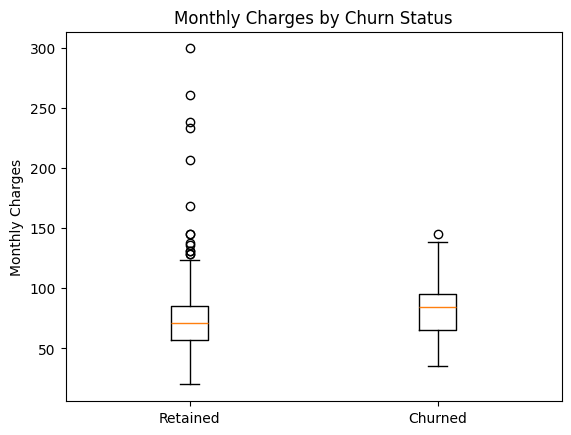

In [15]:
# Extract MonthlyCharges for customers who did not churn
# dropna() removes missing MonthlyCharges values
# Extract MonthlyCharges for retained customers.
group0 = df[df["Churn"] == 0]["MonthlyCharges"].dropna()

# Extract MonthlyCharges for customers who churned
# Extract MonthlyCharges for churned customers.
group1 = df[df["Churn"] == 1]["MonthlyCharges"].dropna()

# Draw two boxplots side by side for comparison
# Create a boxplot.
plt.boxplot(
    [group0, group1],

    # Give meaningful names to the two groups
    tick_labels=["Retained", "Churned"]
)

# Label the y-axis
# Label the y-axis.
plt.ylabel("Monthly Charges")

# Add a title
# Add a descriptive graph title.
plt.title("Monthly Charges by Churn Status")

# Display the comparison
# Display the graph.
plt.show()

### Interpretation

Compare:

- Median
- Spread
- Outliers
- Difference between groups

If the distributions differ strongly, the feature may be useful for prediction.

---

## 4.8 Correlation Heatmap

A correlation matrix may contain many values. A heatmap makes the overall pattern easier to inspect.

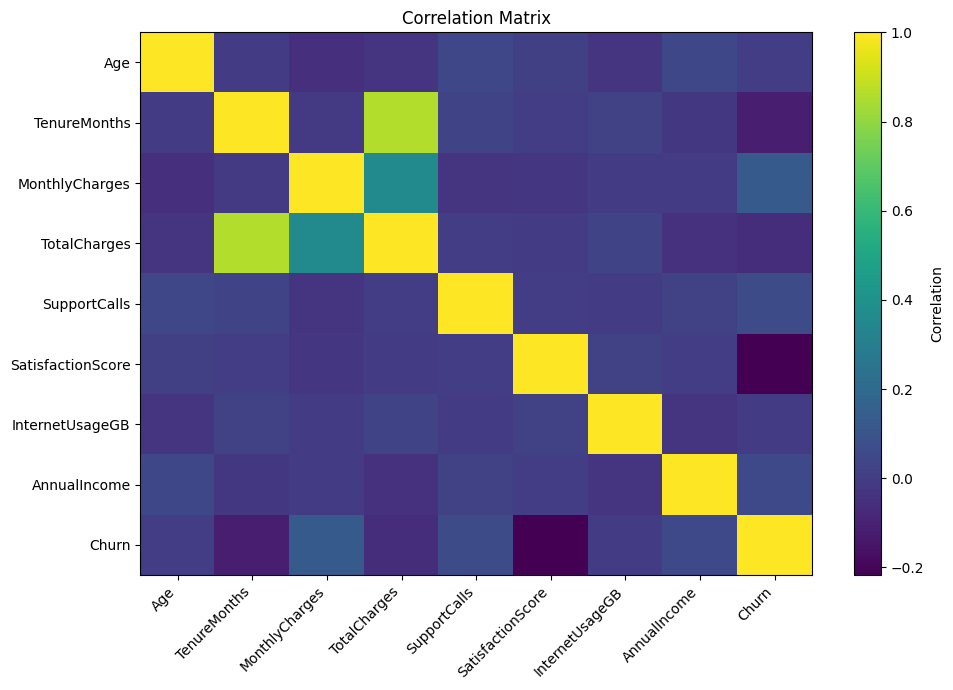

In [16]:
# Import NumPy for numerical operations
# Import NumPy for numerical operations.
import numpy as np

# Select only numerical columns and calculate their Pearson correlation matrix
# Select numerical columns and calculate their correlation matrix.
corr = df.select_dtypes(include="number").corr()

# Create a figure large enough for all feature names
# Create a new figure with the specified size.
plt.figure(figsize=(10, 7))

# Display the correlation matrix as an image
# aspect="auto" lets matplotlib adjust the cell proportions
plt.imshow(corr, aspect="auto")

# Add a color scale showing correlation strength
# Add a color scale to interpret the heatmap.
plt.colorbar(label="Correlation")

# Put feature names on the x-axis
# Adjust x-axis tick labels for readability.
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

# Put feature names on the y-axis
# Set y-axis tick labels.
plt.yticks(
    range(len(corr.index)),
    corr.index
)

# Add a title
# Add a descriptive graph title.
plt.title("Correlation Matrix")

# Adjust spacing so labels fit properly
# Adjust spacing so plot elements do not overlap.
plt.tight_layout()

# Display the heatmap
# Display the graph.
plt.show()

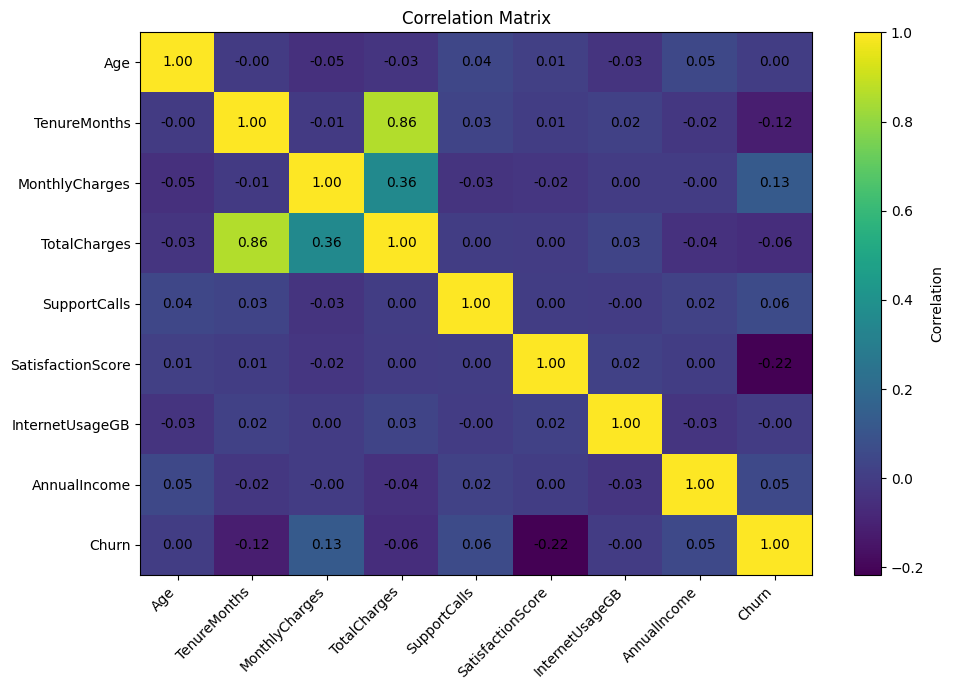

In [18]:
# Import NumPy for numerical operations
import numpy as np

# Select only numerical columns and calculate their Pearson correlation matrix
corr = df.select_dtypes(include="number").corr()

# Create a figure large enough for all feature names
plt.figure(figsize=(10, 7))

# Display the correlation matrix as an image
# aspect="auto" lets matplotlib adjust the cell proportions
plt.imshow(corr, aspect="auto")

# Add a color scale showing correlation strength
plt.colorbar(label="Correlation")

# Put feature names on the x-axis
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

# Put feature names on the y-axis
plt.yticks(
    range(len(corr.index)),
    corr.index
)

# Display correlation values inside each cell
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

# Add a title
plt.title("Correlation Matrix")

# Adjust spacing so labels fit properly
plt.tight_layout()

# Display the heatmap
plt.show()

Use this to identify strongly related numerical features before feature selection.

---

## 4.9 Visualizing Missing Values

Missing-value percentages can also be visualized.

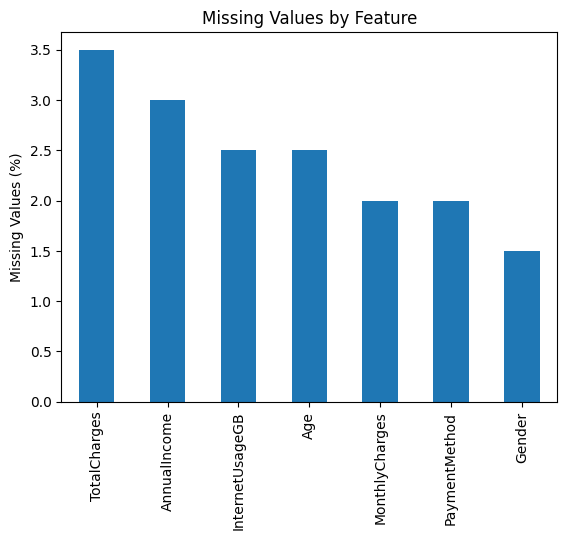

In [17]:
# Calculate the percentage of missing values in every column
# Calculate the percentage of missing values in each column.
missing_percentage = (
    df.isnull().mean() * 100

# Sort columns from highest to lowest missing percentage
).sort_values(ascending=False)

# Keep only columns that actually contain missing values
missing_percentage[
    missing_percentage > 0

# Plot their missing-value percentages as a bar chart
].plot(kind="bar")

# Label the y-axis
# Label the y-axis.
plt.ylabel("Missing Values (%)")

# Add a title
# Add a descriptive graph title.
plt.title("Missing Values by Feature")

# Display the graph
# Display the graph.
plt.show()

This immediately identifies the columns requiring attention.

---

## 4.10 Visualization Checklist

Before moving to modeling, inspect:

1. Numerical distributions
2. Categorical frequencies
3. Target distribution
4. Potential outliers
5. Numerical relationships
6. Feature differences across target classes
7. Correlation among numerical features
8. Missing-value patterns

<div style="background:#E8F5E9;padding:10px;border-left:5px solid #2E7D32;">
<b>Key Takeaway:</b> Good visualization should lead to a preprocessing or modeling decision. For example, a skewed histogram may suggest transformation, a boxplot may trigger outlier investigation, and a class-count plot may indicate imbalance handling.
</div>

---


# 5. Correlation Analysis

**Correlation** measures the strength and direction of the relationship between two variables.

Correlation ranges from **-1 to +1**.

| Value | Meaning |
|---|---|
| +1 | Strong positive relationship |
| 0 | No linear relationship |
| -1 | Strong negative relationship |

Example:

If customer tenure increases and total charges also increase, the correlation is positive.

In [ ]:
# Select numerical columns and compute their Pearson correlation matrix
# Select numerical columns and calculate their correlation matrix.
corr = df.select_dtypes(include="number").corr()

# Print the matrix so we can inspect relationships between numerical features
# Display the result.
print(corr)

### Pearson Correlation

Used mainly for **linear relationships between numerical variables**.

### Spearman Correlation

Used when the relationship is monotonic, ordinal, non-normal, or affected by outliers.

In [ ]:
# Compute Spearman correlation for numerical columns
# Spearman correlation is useful for monotonic or non-linear ranked relationships
df.select_dtypes(include="number").corr(method="spearman")

<div style="background:#FFEBEE;padding:10px;border-left:5px solid #D32F2F;">
<b>Remember:</b> Correlation does not prove causation.
</div>

---

# 6. Outlier Detection

An **outlier** is an observation that is unusually far from most other observations.

Examples:

- Age = 250
- Monthly bill = ₹5,00,000 when normal bills are around ₹1,000

Outliers may be:

- Data-entry errors
- Measurement errors
- Rare but genuine observations
- Fraud/anomalies

Therefore, an outlier should be **investigated before deletion**.

---

## IQR Method

The Interquartile Range is:

**IQR = Q3 − Q1**

Outlier limits:

- Lower = Q1 − 1.5 × IQR
- Upper = Q3 + 1.5 × IQR

In [ ]:
# Calculate the first quartile (25th percentile)
# Calculate the first quartile (Q1).
q1 = df["MonthlyCharges"].quantile(0.25)

# Calculate the third quartile (75th percentile)
# Calculate the third quartile (Q3).
q3 = df["MonthlyCharges"].quantile(0.75)

# Interquartile Range (IQR) measures the spread of the middle 50% of values
# Calculate the interquartile range: Q3 minus Q1.
iqr = q3 - q1

# Calculate the lower boundary for possible outliers
# Calculate the lower IQR outlier boundary.
lower = q1 - 1.5 * iqr

# Calculate the upper boundary for possible outliers
# Calculate the upper IQR outlier boundary.
upper = q3 + 1.5 * iqr

# Select rows where MonthlyCharges lies outside the IQR boundaries
# Select rows outside the IQR boundaries.
outliers = df[
    (df["MonthlyCharges"] < lower) |
    (df["MonthlyCharges"] > upper)
]

# Display the observations identified as potential outliers
# Display the result.
print(outliers)

Possible treatments:

- Correct the value
- Remove invalid observations
- Cap extreme values
- Apply transformation

---


# 7. Feature Selection

**Feature selection** is the process of choosing the most relevant input variables and removing features that are irrelevant, redundant, noisy, or unnecessarily complex.

Suppose a dataset contains 100 variables but only 15 provide useful information about the target. Training a model on all 100 variables may increase complexity without improving prediction.

## Why is Feature Selection Important?

Feature selection can:

- Reduce model complexity
- Reduce training time
- Improve interpretability
- Reduce noise
- Reduce overfitting
- Remove redundant information
- Help some models generalize better

<div style="background:#FFF8E1;padding:10px;border-left:5px solid #FFB300;">
<b>Important distinction:</b> Feature selection keeps or removes existing features. Feature transformation changes features into a new representation.
</div>

Example:

- **Feature Selection:** Remove `CustomerID`
- **Feature Transformation:** Convert `AnnualIncome` into `log(AnnualIncome)`

---

## 7.1 Which Features Should We Consider Removing?

### 1. Identifier Features

Identifiers usually describe the record rather than the phenomenon being predicted.

Examples:

- Customer ID
- Roll number
- Transaction ID

In [ ]:
# Create the input-feature matrix X
# Remove CustomerID because it is an identifier
# Remove Churn because it is the target we want to predict
# Create the input-feature matrix by removing identifier/target columns.
X = df.drop(columns=["CustomerID", "Churn"])

# Store the target variable separately in y
# Store the target variable separately.
y = df["Churn"]

`CustomerID` is unique but normally has no meaningful relationship with churn.

---

## 7.2 Constant and Near-Constant Features

A feature containing almost the same value for every observation contains little useful information.

In [ ]:
# Count the number of unique values present in every column
# A column with only one unique value is a constant feature
# Count unique values in every column.
print(df.nunique())

A feature with only one unique value is constant.

Example:

```text
Country = India
Country = India
Country = India
...
```

Such a feature cannot help distinguish observations.

---

## 7.3 Correlation-Based Feature Selection

Highly correlated predictors may contain similar information.

In [ ]:
# Keep only numerical columns because correlation is calculated on numerical data
# Keep only numerical columns.
numeric_df = df.select_dtypes(include="number")

# Calculate the absolute correlation values
# abs() removes the sign because both strong positive and strong negative
# correlations can indicate redundancy
# Calculate absolute correlation values to inspect redundancy.
corr = numeric_df.corr().abs()

# Display the correlation matrix
# Display the result.
print(corr)

Example:

`TotalCharges` may be strongly related to:

- `MonthlyCharges`
- `TenureMonths`

because total charges depend partly on monthly payment and duration.

### Important

Do not automatically remove every correlated feature.

Consider:

- Domain meaning
- Model type
- Interpretability
- Predictive performance

---

# 7.4 Three Main Feature-Selection Approaches

There are three major families:

1. **Filter Methods**
2. **Wrapper Methods**
3. **Embedded Methods**

| Method | Main Idea | Speed |
|---|---|---|
| Filter | Statistical relationship with target | Fast |
| Wrapper | Evaluate subsets using a model | Slower |
| Embedded | Selection occurs during training | Moderate |

---

# 7.5 Filter Methods

Filter methods select features using statistical properties **before or independently of the final predictive model**.

Examples:

- Correlation
- Chi-square test
- ANOVA F-test
- Mutual Information
- Variance threshold

### Advantages

- Fast
- Easy to understand
- Suitable for high-dimensional datasets

### Limitation

They may not consider interactions between features.

---

## SelectKBest with ANOVA F-test

For numerical features and a categorical target:

In [ ]:
# Import SelectKBest and the ANOVA F-test scoring function
# Import SelectKBest and the ANOVA F-test scoring function.
from sklearn.feature_selection import SelectKBest, f_classif

# Define the numerical features that will be evaluated
# Define the numerical features to be evaluated.
features = [
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "SupportCalls",
    "SatisfactionScore",
    "InternetUsageGB",
    "AnnualIncome"
]

# Create the feature matrix using only the selected columns
# copy() prevents accidental modification of the original DataFrame
# Create the feature matrix using the selected columns.
X = df[features].copy()

# Fill missing numerical values with each column's median
# Feature-selection methods cannot work properly with NaN values
# Fill missing numerical values with the median.
X = X.fillna(X.median())

# Store the target variable
# Store the target variable separately.
y = df["Churn"]

# Create a SelectKBest object
# Create a SelectKBest feature selector.
selector = SelectKBest(
    # f_classif computes an ANOVA F-score for each feature
    score_func=f_classif,

    # Keep the 4 highest-scoring features
    k=4
)

# Learn the feature scores from X and y
# Fit the feature selector using X and y.
selector.fit(X, y)

See selected features:

In [ ]:
# get_support() returns True for selected features and False for rejected features
# Extract the names of the selected features.
selected_features = X.columns[
    selector.get_support()
]

# Display the names of the features selected by SelectKBest
# Display the result.
print(selected_features)

See scores:

In [ ]:
# Import pandas for creating a result table
# Import pandas for reading and working with tabular data.
import pandas as pd

# Build a DataFrame that summarizes the feature-selection result
# Create a table summarizing feature-selection scores.
scores = pd.DataFrame({
    # Original feature names
    "Feature": X.columns,

    # ANOVA F-score calculated for each feature
    "Score": selector.scores_,

    # True means the feature is among the selected top-k features
    "Selected": selector.get_support()
})

# Sort features from highest to lowest F-score before printing
# Display the result.
print(
    scores.sort_values(
        "Score",
        ascending=False
    )
)

### Interpretation

A larger F-score indicates a stronger difference between target classes for that feature.

However, the score alone does not guarantee that the feature will improve every model.

---

## Mutual Information

Mutual Information can capture some non-linear dependency.

In [ ]:
# Import Mutual Information for classification problems
# Import Mutual Information for classification problems.
from sklearn.feature_selection import mutual_info_classif

# Calculate how much information each feature provides about the target
# Calculate Mutual Information scores.
mi_scores = mutual_info_classif(
    X,
    y,

    # Fix randomness so results are reproducible
    random_state=42
)

# Convert the scores into a labelled pandas Series
# Convert Mutual Information scores into a labelled Series.
mi = pd.Series(
    mi_scores,
    index=X.columns

# Sort features from highest to lowest Mutual Information score
).sort_values(ascending=False)

# Display the ranking
# Display the result.
print(mi)

### Difference from simple correlation

Correlation mainly measures linear association.

Mutual information can identify broader dependencies between a feature and the target.

---

# 7.6 Wrapper Methods

Wrapper methods select features by actually training a machine-learning model with different subsets.

They ask:

> Which subset of features produces the best model performance?

Examples:

- Recursive Feature Elimination (RFE)
- Sequential Forward Selection
- Sequential Backward Selection

### Advantages

- Considers the predictive model
- Can identify useful combinations of features

### Disadvantages

- More computationally expensive
- May overfit if not validated carefully

---

## Recursive Feature Elimination (RFE)

RFE repeatedly removes less important features until the required number remains.

In [ ]:
# Import Recursive Feature Elimination (RFE)
# Import Recursive Feature Elimination (RFE).
from sklearn.feature_selection import RFE

# Logistic Regression will be the estimator used to judge feature usefulness
# Import Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter is increased to give the optimizer enough iterations to converge
# Create a Logistic Regression model.
model = LogisticRegression(
    max_iter=1000
)

# Create the RFE selector
# Create the RFE selector.
rfe = RFE(
    # Use Logistic Regression to evaluate feature importance
    estimator=model,

    # Continue eliminating features until only 4 remain
    n_features_to_select=4
)

# Run recursive feature elimination on the training data
# Run recursive feature elimination.
rfe.fit(X, y)

Check selection:

In [ ]:
# Create a table showing the result of RFE
# Create a table showing RFE results.
rfe_result = pd.DataFrame({
    # Feature names
    "Feature": X.columns,

    # True means the feature was retained
    "Selected": rfe.support_,

    # Rank 1 means selected; larger ranks mean the feature was removed earlier
    "Ranking": rfe.ranking_
})

# Display the RFE selection result
# Display the result.
print(rfe_result)

### Interpretation

- `Selected = True` → feature retained
- `Ranking = 1` → selected feature
- Higher rank → removed earlier

---

# 7.7 Embedded Methods

Embedded methods perform feature selection **during model training**.

Examples:

- Lasso Regression
- Logistic Regression with L1 penalty
- Decision Trees
- Random Forest
- Gradient Boosting

They provide a balance between filter and wrapper methods.

---

## Random Forest Feature Importance

In [ ]:
# Import the Random Forest classifier
# Import the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest containing 200 decision trees
# Create a Random Forest classifier.
rf = RandomForestClassifier(
    n_estimators=200,

    # Fix randomness so the experiment can be reproduced
    random_state=42
)

# Train the Random Forest using the feature matrix and target
# Train the Random Forest model.
rf.fit(X, y)

# Extract the importance assigned to each feature by the trained forest
# Store feature-importance values with feature names.
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns

# Sort from highest to lowest importance
).sort_values(ascending=False)

# Display the feature-importance ranking
# Display the result.
print(importance)

Visualize importance:

In [ ]:
# Sort feature importance from low to high so the horizontal bars are easy to compare
# Visualize feature importance using a horizontal bar chart.
importance.sort_values().plot(
    kind="barh"
)

# Label the x-axis
# Label the x-axis.
plt.xlabel("Importance")

# Add a title
# Add a descriptive graph title.
plt.title("Random Forest Feature Importance")

# Display the graph
# Display the graph.
plt.show()

### Interpretation

Features with larger importance contributed more strongly to the tree ensemble's decisions.

### Caution

Feature importance is model-dependent.

A feature considered important by Random Forest may not have the same importance in Logistic Regression.

---

# 7.8 L1 Regularization for Feature Selection

L1 regularization can force some coefficients toward exactly zero.

In [ ]:
# Import Logistic Regression
# Import Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression with L1 regularization
# Create a Logistic Regression model.
model = LogisticRegression(
    # L1 can shrink some coefficients exactly to zero
    penalty="l1",

    # liblinear supports L1 regularization for this type of problem
    solver="liblinear",

    # Increase maximum iterations to help the model converge
    max_iter=1000
)

# Train the model so it can learn a coefficient for every feature
# Train the model.
model.fit(X, y)

Inspect coefficients:

In [ ]:
# Convert the learned coefficients into a labelled pandas Series
# Store learned coefficients with feature names.
coefficients = pd.Series(
    # model.coef_[0] contains one coefficient for each input feature
    model.coef_[0],

    # Use feature names as labels
    index=X.columns
)

# Display the coefficients
# Values equal or close to zero indicate features with little contribution under this model
# Display the result.
print(coefficients)

Features with coefficients equal or close to zero contribute little under this model.

---

# 7.9 Comparing Feature-Selection Methods

A useful classroom comparison is:

```text
Correlation / ANOVA
        ↓
     Filter

RFE + Logistic Regression
        ↓
     Wrapper

Random Forest / L1
        ↓
     Embedded
```

The selected features may differ because each method asks a different question.

### Filter asks:

> Is this feature statistically related to the target?

### Wrapper asks:

> Does this feature improve this specific model when used with other features?

### Embedded asks:

> How important is this feature during model training?

---

# 7.10 Feature Selection vs Feature Extraction

These terms should not be confused.

### Feature Selection

Keeps a subset of original features.

Example:

```text
Original:
Age, Income, Tenure, Charges, SupportCalls

Selected:
Tenure, Charges, SupportCalls
```

### Feature Extraction

Creates new features from existing features.

Example:

PCA transforms many original variables into new principal components.

PCA is covered later under dimensionality reduction.

---

# 7.11 Practical Feature-Selection Workflow

A sensible sequence is:

### Step 1
Remove identifiers and obviously irrelevant columns.

### Step 2
Check constant or near-constant features.

### Step 3
Study correlation and redundancy.

### Step 4
Apply a filter technique.

### Step 5
Apply a model-based technique.

### Step 6
Compare model performance before and after selection.

<div style="background:#E8F5E9;padding:10px;border-left:5px solid #2E7D32;">
<b>Most important rule:</b> The final decision should not be based only on a feature-selection score. Verify whether the selected feature subset improves validation performance and still makes sense for the problem domain.
</div>

---

## Quick Comparison

| Technique | Category | Useful When |
|---|---|---|
| Correlation | Filter | Removing redundant numerical variables |
| ANOVA F-test | Filter | Numerical input + categorical target |
| Mutual Information | Filter | Possible non-linear dependency |
| RFE | Wrapper | Selecting features for a specific model |
| L1 Regularization | Embedded | Sparse linear/logistic models |
| Random Forest Importance | Embedded | Tree-based feature ranking |

---


# 8. Feature Transformation

**Feature transformation** changes the representation or scale of a feature to make it more suitable for machine learning.

---

## Standardization

Transforms data so that approximately:

- Mean = 0
- Standard deviation = 1

In [ ]:
# Import StandardScaler
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Create the scaler
# Create a StandardScaler object.
scaler = StandardScaler()

# Standardize Age and MonthlyCharges
# fillna(0) is used here only to avoid missing-value errors in this simple example
# fit_transform() learns the mean/std and then transforms the data
# Learn scaling parameters and transform the selected features.
scaled = scaler.fit_transform(
    df[["Age", "MonthlyCharges"]].fillna(0)
)

Scaling is important for:

- KNN
- SVM
- Logistic Regression
- PCA
- Neural Networks

---

## Min-Max Scaling

Converts values usually to the range **0 to 1**.

In [ ]:
# Import MinMaxScaler
# Import MinMaxScaler.
from sklearn.preprocessing import MinMaxScaler

# Create the scaler
# Create a MinMaxScaler object.
scaler = MinMaxScaler()

# Scale Age and MonthlyCharges, usually into the range 0 to 1
# fit_transform() first learns min/max values and then applies the scaling
# Learn scaling parameters and transform the selected features.
scaled = scaler.fit_transform(
    df[["Age", "MonthlyCharges"]].fillna(0)
)

---

## Log Transformation

Useful for highly positively skewed data such as salary or income.

In [ ]:
# Import NumPy for mathematical transformations
# Import NumPy for numerical operations.
import numpy as np

# Apply log(1 + x) to AnnualIncome
# log1p is safer than log(x) when a value can be zero
# The transformation can reduce strong positive skewness
# Apply log(1 + x) transformation to AnnualIncome.
df["LogIncome"] = np.log1p(df["AnnualIncome"])

It compresses very large values and can reduce skewness.

---

## Categorical Encoding

Machine-learning algorithms usually require numerical inputs.

For nominal categories, **One-Hot Encoding** is commonly used.

In [ ]:
# Convert each ContractType category into separate 0/1 indicator columns
# This is called one-hot encoding and avoids introducing an artificial order
# Apply one-hot encoding to the categorical feature.
pd.get_dummies(df["ContractType"])

Avoid assigning artificial order such as:

`North=1, South=2, East=3, West=4`

because it may incorrectly suggest that one category is greater than another.

---

# 9. Data Imbalance Handling

A dataset is **imbalanced** when one target class has many more samples than another.

Example:

- Class 0 = 90%
- Class 1 = 10%

A model predicting every case as Class 0 would obtain 90% accuracy but would completely fail to detect Class 1.

### Check class balance

In [ ]:
# Display the number of observations in each churn class
# Count observations in each target class.
df["Churn"].value_counts()

# Display the proportion of observations in each churn class
# normalize=True returns relative frequencies instead of raw counts
# Count observations in each target class.
df["Churn"].value_counts(normalize=True)

For imbalanced data, also consider:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Balanced Accuracy

---

## Common Techniques

### 1. Oversampling

Increase minority-class observations.

### 2. Undersampling

Reduce majority-class observations.

### 3. SMOTE

SMOTE creates synthetic minority-class samples.

In [ ]:
# Import SMOTE for oversampling the minority class
# Import SMOTE for oversampling the minority class.
from imblearn.over_sampling import SMOTE

# Create the SMOTE object
# random_state ensures reproducible synthetic samples
# Create the SMOTE oversampler.
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to the training data
# X_resampled and y_resampled contain the balanced training set
# Apply SMOTE to the training data.
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

### 4. Class Weighting

In [ ]:
# Import Logistic Regression
# Import Logistic Regression.
from sklearn.linear_model import LogisticRegression

# Create a model that automatically gives more weight to the minority class
# Create a Logistic Regression model.
model = LogisticRegression(
    # "balanced" adjusts class weights inversely according to class frequency
    class_weight="balanced",

    # Allow enough iterations for the optimizer to converge
    max_iter=1000
)

<div style="background:#FFEBEE;padding:10px;border-left:5px solid #D32F2F;">
<b>Important:</b> Apply SMOTE only to training data, not before train-test splitting. Otherwise, data leakage may occur.
</div>

---

# 10. Data Preprocessing Pipeline

A **pipeline** combines multiple preprocessing steps into one workflow.

Typical flow:

**Missing-value treatment → Encoding → Scaling → Model**

Why use a pipeline?

- Prevents data leakage
- Makes code reusable
- Ensures the same preprocessing is applied to training and testing data
- Makes model deployment easier

---

## Numerical Pipeline

In [ ]:
# Import Pipeline so multiple preprocessing steps can be chained together
# Import Pipeline so preprocessing steps can be chained together.
from sklearn.pipeline import Pipeline

# SimpleImputer will fill missing values
# Import SimpleImputer for handling missing values.
from sklearn.impute import SimpleImputer

# StandardScaler will standardize numerical features
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Create the numerical preprocessing pipeline
# Create the numerical preprocessing pipeline.
numeric_pipeline = Pipeline([
    # Step 1: replace missing numerical values with the median
    ("imputer", SimpleImputer(strategy="median")),

    # Step 2: standardize the numerical values
    ("scaler", StandardScaler())
])

## Categorical Pipeline

In [ ]:
# Import OneHotEncoder for converting categories into numerical indicator columns
# Import OneHotEncoder for converting categories into indicator columns.
from sklearn.preprocessing import OneHotEncoder

# Create the categorical preprocessing pipeline
# Create the categorical preprocessing pipeline.
categorical_pipeline = Pipeline([
    # Step 1: replace missing categories with the most frequent category
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Step 2: one-hot encode the categories
    # handle_unknown="ignore" prevents errors if a new category appears in test data
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Combine Both

In [ ]:
# Import ColumnTransformer so different preprocessing can be applied
# to numerical and categorical columns
# Import ColumnTransformer to apply different preprocessing to different column groups.
from sklearn.compose import ColumnTransformer

# Combine the numerical and categorical pipelines
# Combine numerical and categorical preprocessing pipelines.
preprocessor = ColumnTransformer([
    # Apply numeric_pipeline to the columns listed in numeric_features
    ("num", numeric_pipeline, numeric_features),

    # Apply categorical_pipeline to the columns listed in categorical_features
    ("cat", categorical_pipeline, categorical_features)
])

---

# 11. Data Leakage

**Data leakage** occurs when information from the test set indirectly enters model training.

### Wrong approach

In [ ]:
# WRONG APPROACH:
# Fit the scaler using the complete dataset before splitting
# This allows information from future test data to influence the scaling
# Fit the scaler on the complete dataset; this illustrates the wrong leakage-prone approach.
X_scaled = scaler.fit_transform(X)

# Split the already-scaled data into training and testing sets
# Because scaling used all rows, data leakage has already occurred
# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)

The scaler has already learned from the complete dataset.

### Better approach

Split first and use a pipeline.

In [ ]:
# BETTER APPROACH:
# Split the original data before fitting preprocessing steps
# Split data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,

    # Keep 20% of the observations for final testing
    test_size=0.2,

    # Fix the random split so results are reproducible
    random_state=42,

    # Preserve approximately the same class proportion in train and test sets
    stratify=y
)

Then:

In [ ]:
# Fit the complete pipeline using ONLY the training data
# Any imputation, scaling, encoding, etc. is learned from X_train
# Fit the complete pipeline using only training data.
pipeline.fit(X_train, y_train)

# Apply the already-fitted pipeline to the test data and generate predictions
# The test set is transformed without being used to learn preprocessing parameters
# Use the fitted pipeline to generate predictions for test data.
pipeline.predict(X_test)

---

# 12. Complete Unit-II Workflow

<div style="background:#E8F5E9;padding:12px;border-left:5px solid #2E7D32;">
<b>Recommended Workflow</b><br><br>
Load Dataset → Understand Data → Check Missing Values → Check Duplicates → Visualize Data → Correlation Analysis → Detect Outliers → Select Features → Transform Features → Check Class Imbalance → Build Preprocessing Pipeline → Train Model
</div>

---

# 13. Quick Revision

| Topic | Purpose |
|---|---|
| EDA | Understand the dataset |
| Visualization | Discover patterns |
| Correlation | Study relationships |
| Outlier Detection | Identify unusual observations |
| Feature Selection | Keep important variables |
| Feature Transformation | Improve feature representation |
| Imbalance Handling | Improve minority-class learning |
| Pipeline | Automate safe preprocessing |

---

## Important Questions

1. What is EDA and why is it required?
2. Differentiate Pearson and Spearman correlation.
3. Explain the IQR method for outlier detection.
4. What is feature selection?
5. Differentiate filter, wrapper, and embedded methods.
6. Why is scaling required?
7. What is class imbalance?
8. Why can accuracy be misleading for imbalanced datasets?
9. What is SMOTE?
10. What is a preprocessing pipeline?
11. What is data leakage?
12. Why should preprocessing be fitted only on training data?